# ResMill Delta Tutorial

Walk through every dial of `DeltaLayer` — the fluvial-engine
distributary-fan delta. Subclass of `MeanderingChannelLayer` driving
the full Alluvsim event-loop fluvial engine (AR(2) walks +
Sun-1996 bank-retreat migration + avulsion-inside + neck cutoff +
level aggradation) with delta-tuned defaults (`DELTA_FAN`).

The fan emerges naturally from the AR(2)-walk + avulsion-inside
physics; aggradation, progradation, trunk meandering, branch fan-out
angle and mouth bars are all controlled by a small number of
dedicated knobs.

## Knobs unique to DeltaLayer

| knob                    | what it does                                                                                            |
|-------------------------|---------------------------------------------------------------------------------------------------------|
| `n_generations`         | number of stacked aggradation levels (each is one independent fluvial sim that fills a Z slab)          |
| `ntime_per_gen`         | event budget per generation                                                                              |
| `trunk_length_fraction` | proximal-node fraction protected from avulsion-inside ⇒ trunk meanders before any branch can split off  |
| `progradation_fraction` | total apex advance along +flow across all generations (0 = pinned, >0 = clinoform)                      |
| `branch_spread_deg`     | std-dev (compass °) of the random perturbation applied to each new branch's launch azimuth              |
| `paint_mouth_bars`      | paint a `calc_lobe` LA-facies bar at every distal streamline tip                                        |

Plus everything from the meandering channel: `mCHsinu`, `mCHwdratio`,
`mCHdepth`, `probAvulInside`, `mCSnum` (crevasse splays), `mFFCHprop`
(abandoned-channel mud-plug fraction), levee parameters, hydraulic
parameters, `azimuth`, etc.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import resmill as rm
from resmill.layers.delta import DeltaLayer, DELTA_FAN

%matplotlib inline

# Standard 64×64×32 grid used by every tutorial + dataset config
GRID = dict(nx=64, ny=64, nz=32, x_len=640, y_len=640, z_len=32, top_depth=0)
print('GRID:', GRID)
print('\nDELTA_FAN preset:')
for k, v in DELTA_FAN.items():
    print(f'  {k:>20s} = {v}')

GRID: {'nx': 64, 'ny': 64, 'nz': 32, 'x_len': 640, 'y_len': 640, 'z_len': 32, 'top_depth': 0}

DELTA_FAN preset:
         n_generations = 8
         ntime_per_gen = 80
             NTGtarget = 0.99
       probAvulOutside = 0.0
        probAvulInside = 0.7
               mCHsinu = 1.1
           stdevCHsinu = 0.02
            mCHwdratio = 14.0
        stdevCHwdratio = 2.0
              mCHdepth = 2.0
          stdevCHdepth = 0.3
         stdevCHsource = 0.2
                mCHazi = 90.0
            stdevCHazi = 0.2
          mdistMigrate = 3.0
      stdevdistMigrate = 1.0
             mFFCHprop = 0.0
         stdevFFCHprop = 0.0
              mLVdepth = 0.5
          stdevLVdepth = 0.1
              mLVwidth = 20.0
          stdevLVwidth = 5.0
             mLVheight = 0.3
         stdevLVheight = 0.1
               mLVasym = 0.0
           stdevLVasym = 0.1
                mCSnum = 0.0
            stdevCSnum = 0.0
                    Cf = 0.0036
          scour_factor = 10.0
           

In [2]:
# Tiny analysis helper used to annotate the plots below.
def fan_metrics(layer):
    a = layer.active.astype(np.int32)
    nx_, ny_, nz_ = a.shape
    prox = a[: nx_ // 4, :, :].sum(axis=(0, 2))
    dist = a[3 * nx_ // 4 :, :, :].sum(axis=(0, 2))
    z_bot = a[:, :, : nz_ // 4].sum()
    z_mid = a[:, :, nz_ // 4 : 3 * nz_ // 4].sum()
    z_top = a[:, :, 3 * nz_ // 4 :].sum()
    return dict(ntg=float(a.sum()) / a.size,
                yspan_prox=int((prox > 0).sum()),
                yspan_dist=int((dist > 0).sum()),
                fan_ratio=int((dist > 0).sum()) / max(int((prox > 0).sum()), 1),
                z_bot=int(z_bot), z_mid=int(z_mid), z_top=int(z_top))

## 1. Default DELTA_FAN — single look

Tight proximal trunk, clean fan downstream, sand bodies span the full
vertical column (no more "channels only at iz=0 and iz=23" — the new
`n_generations`-driven aggradation fills the middle).

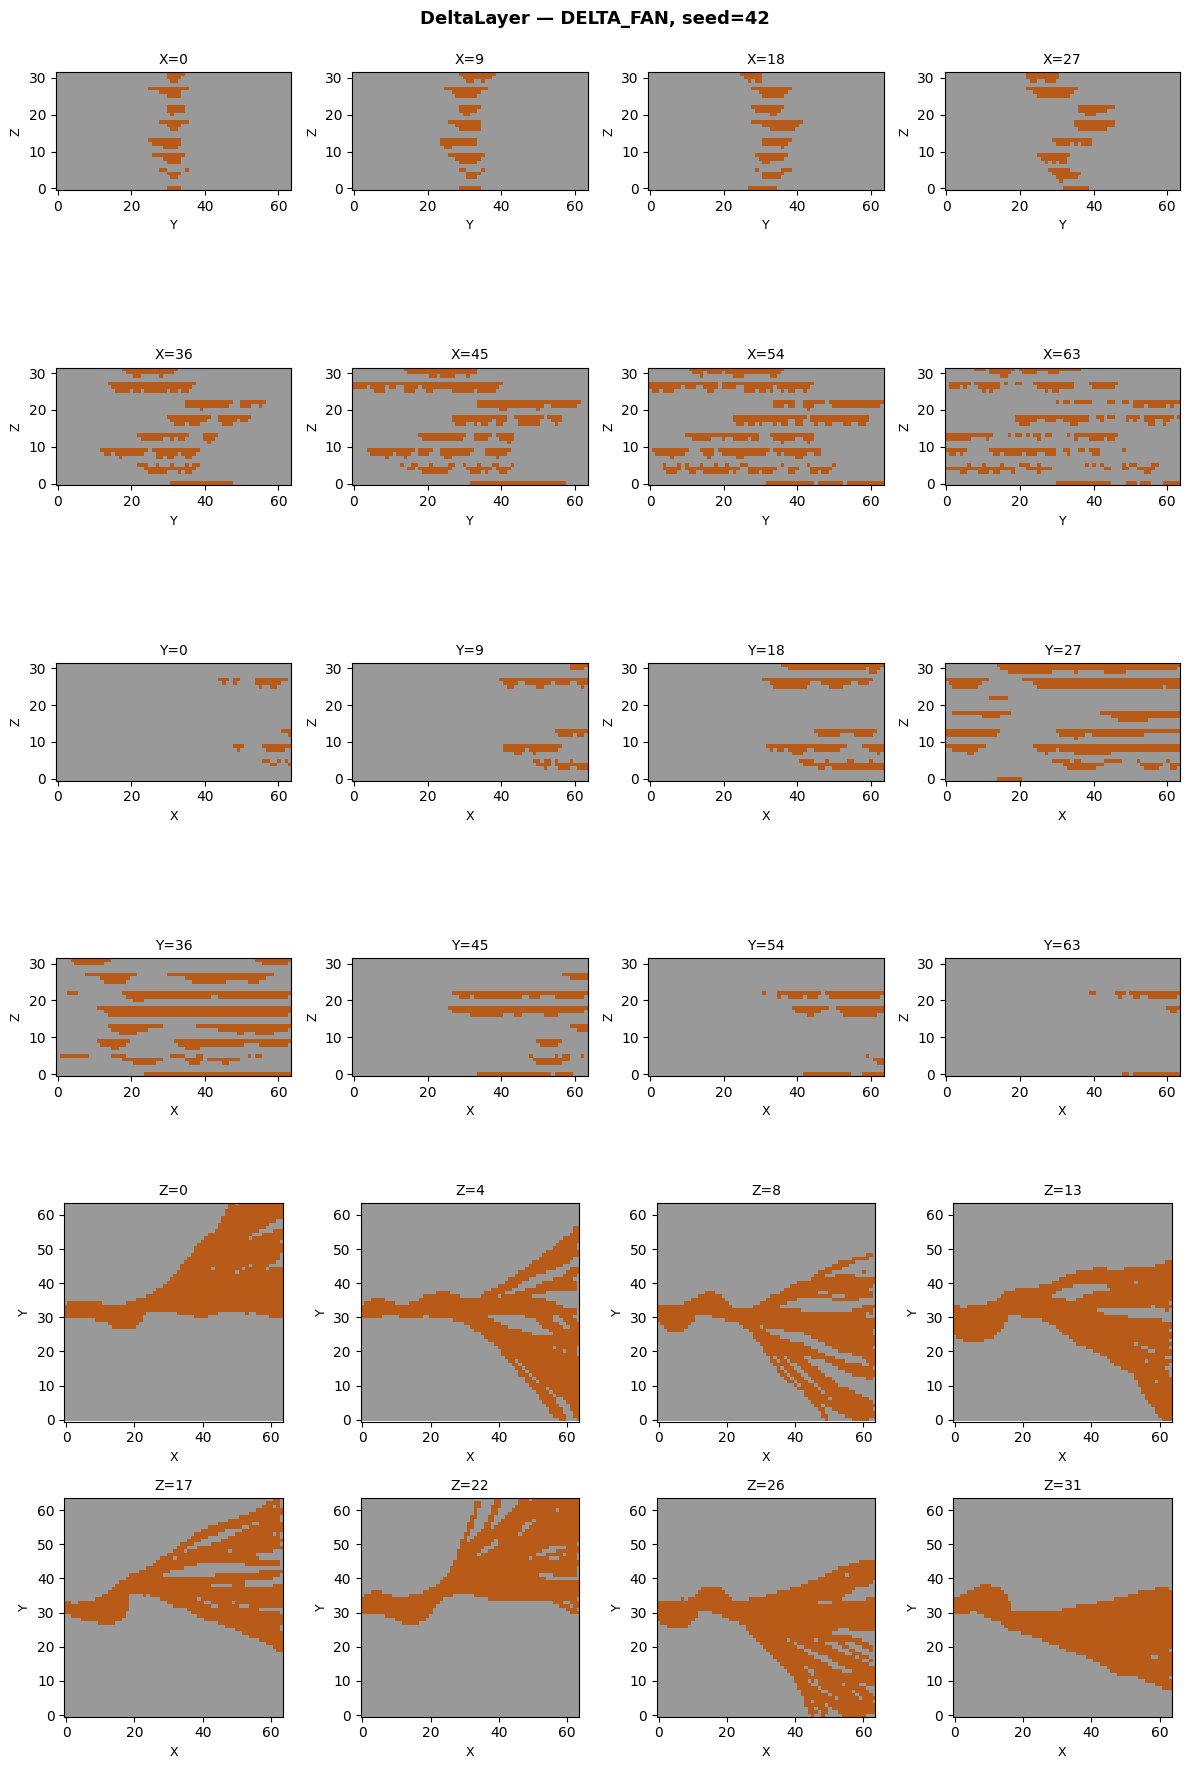

{'ntg': 0.14284515380859375, 'yspan_prox': 17, 'yspan_dist': 64, 'fan_ratio': 3.764705882352941, 'z_bot': 3544, 'z_mid': 9602, 'z_top': 5577}


In [3]:
layer = DeltaLayer(**GRID)
layer.create_geology(seed=42)
rm.plot_slices(layer, facies='binary', title='DeltaLayer — DELTA_FAN, seed=42')
print(fan_metrics(layer))

## 2. Trunk meanders before bifurcating — `trunk_length_fraction`

**The new control:** `trunk_length_fraction` zeroes the avulsion-inside
weights for the proximal portion of every streamline, so a fresh tail
can only be spliced onto the *distal* part of the channel. The trunk
stays a single meandering channel for that fraction; bifurcation only
starts downstream.

* `trunk_length_fraction = 0.0` ⇒ Alluvsim default — bifurcation can
  start from the very first node (looks more like a braided plain).
* `trunk_length_fraction ≈ 0.3 - 0.5` (default 0.4) ⇒ classic
  delta-plain: a single trunk meanders for 40 % of the streamline,
  then the distributary fan opens.
* `trunk_length_fraction = 0.7+` ⇒ a long trunk and only a small
  bifurcating tip — terminal-fan / Birdfoot-style architecture.

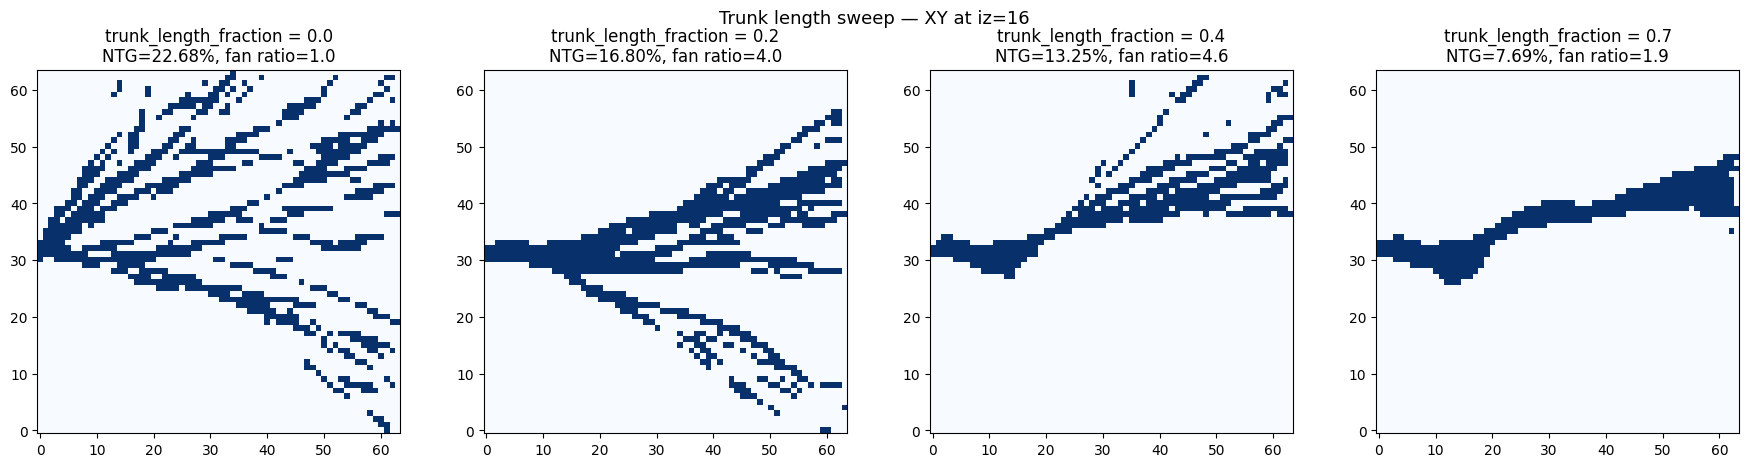

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
iz = GRID['nz'] // 2
for ax, tf in zip(axes, [0.0, 0.2, 0.4, 0.7]):
    layer = DeltaLayer(**GRID)
    layer.create_geology(seed=7, trunk_length_fraction=tf)
    ax.imshow(layer.active[:, :, iz].T, origin='lower', cmap='Blues', vmin=0, vmax=1)
    m = fan_metrics(layer)
    ax.set_title(f'trunk_length_fraction = {tf}\nNTG={m["ntg"]:.2%}, fan ratio={m["fan_ratio"]:.1f}')
fig.suptitle(f'Trunk length sweep — XY at iz={iz}', fontsize=13)
fig.tight_layout(); plt.show()

## 3. Aggradation — `n_generations`

**Aggradation** is the vertical stacking of the channel system. Each
generation paints channels at its own `chelev` (channel elevation),
spanning the Z column from `dz` up to `z_len`. Without aggradation
(`n_generations = 1`) you get one slab of channels at one Z; with
many generations the column fills bottom-to-top.

**Why XY at iz=12 was empty before:** the original DELTA_FAN preset
used `nlevel=2` and the engine's NTG-driven level switching would
burn its entire event budget on the bottom level before reaching the
top, so middle-Z slices stayed empty. The new DeltaLayer drives
`n_generations` independent single-level engine runs and merges the
facies cubes — every generation gets its own event budget and the
middle Z cells fill in correctly.

Default `n_generations = 8`. Lower values leave Z gaps; higher values
are slower but smoother.

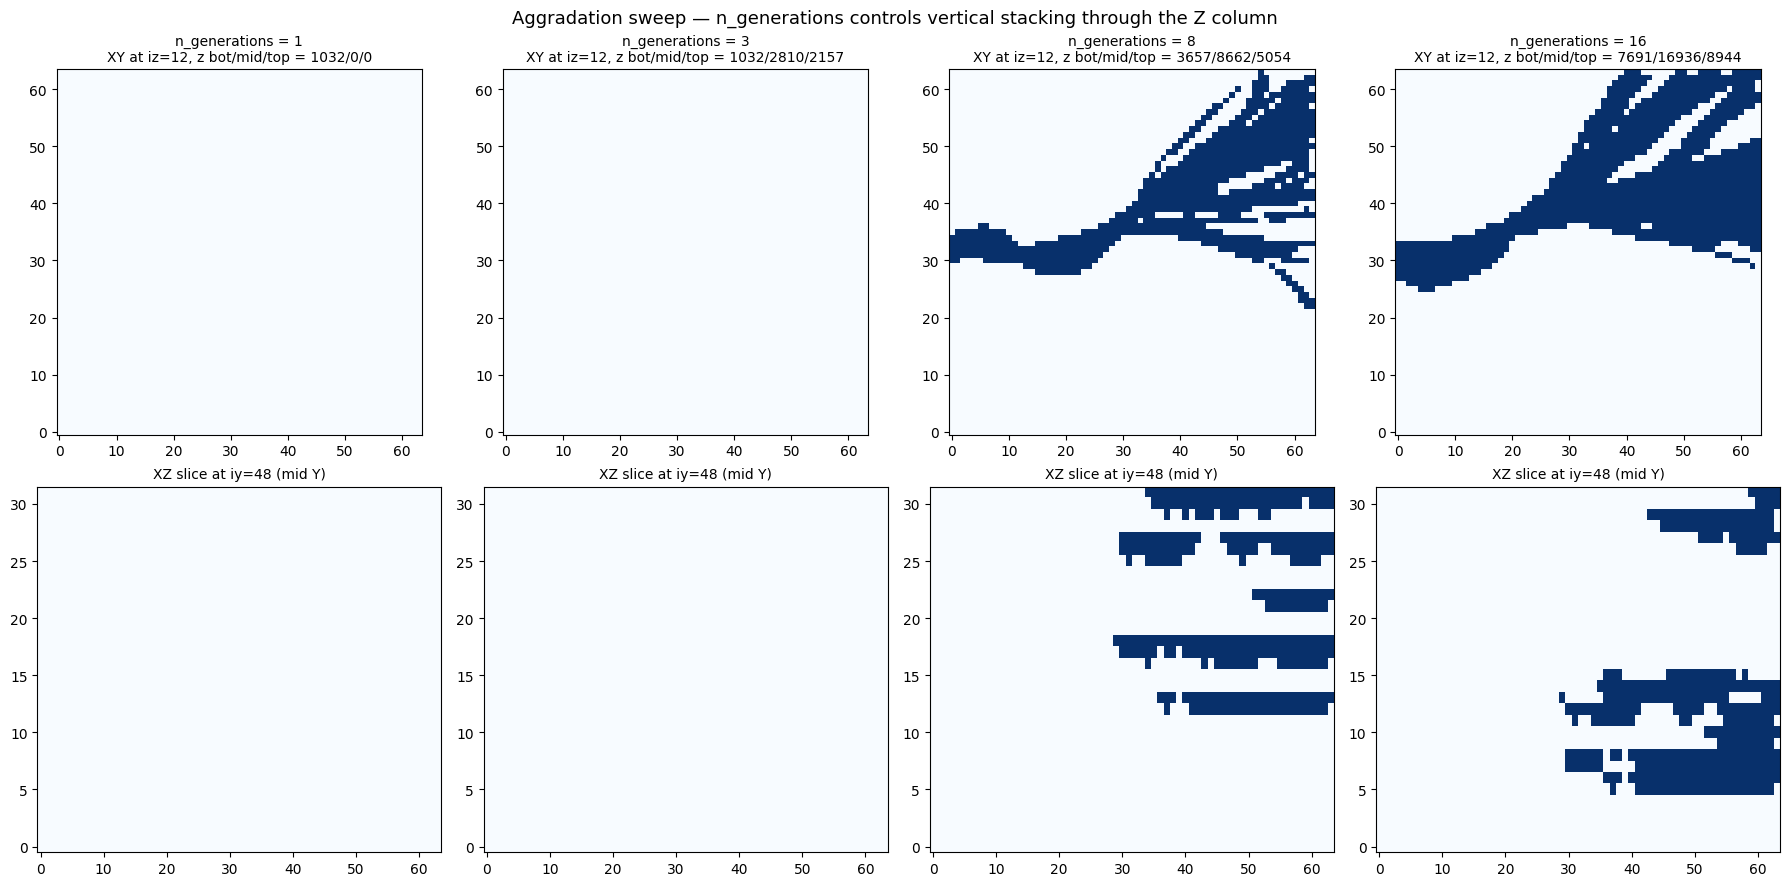

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for col, ngen in enumerate([1, 3, 8, 16]):
    layer = DeltaLayer(**GRID)
    layer.create_geology(seed=7, n_generations=ngen)
    a = layer.active.astype(np.int32)
    iz = 12
    axes[0, col].imshow(a[:, :, iz].T, origin='lower', cmap='Blues',
                         aspect='equal', vmin=0, vmax=1)
    m = fan_metrics(layer)
    axes[0, col].set_title(f'n_generations = {ngen}\nXY at iz={iz}, '
                            f'z bot/mid/top = {m["z_bot"]}/{m["z_mid"]}/{m["z_top"]}',
                            fontsize=10)
    axes[1, col].imshow(a[:, 48, :].T, origin='lower', cmap='Blues',
                         aspect='auto', vmin=0, vmax=1)
    axes[1, col].set_title(f'XZ slice at iy=48 (mid Y)', fontsize=10)
fig.suptitle('Aggradation sweep — n_generations controls vertical stacking through the Z column',
              fontsize=13)
fig.tight_layout()
plt.show()

## 4. Progradation — `progradation_fraction`

**Progradation** is the seaward (downstream) advance of the apex over
geological time as sediment fills the basin and the shoreline moves
out. In our model: `progradation_fraction = f` advances the streamline
entry from `xmin` (generation 0) to `xmin + f * x_len` (last
generation), so each successive generation paints its trunk + fan
shifted further toward +flow. Stacked vertically this builds the
classic **clinoform** seen in delta seismic sections.

* `progradation_fraction = 0.0` (default) — apex stays at the entry;
  pure aggradation, vertical sand sheet.
* `progradation_fraction ≈ 0.3 - 0.5` — clinoform: each generation's
  apex sits ~3-6 % of the grid further downstream than the previous;
  in the XZ slice the channels climb up-and-out.
* `progradation_fraction ≈ 0.6+` — strongly prograding (basin-shoaling)
  delta where late-generation channels run across the distal half
  of the grid only.

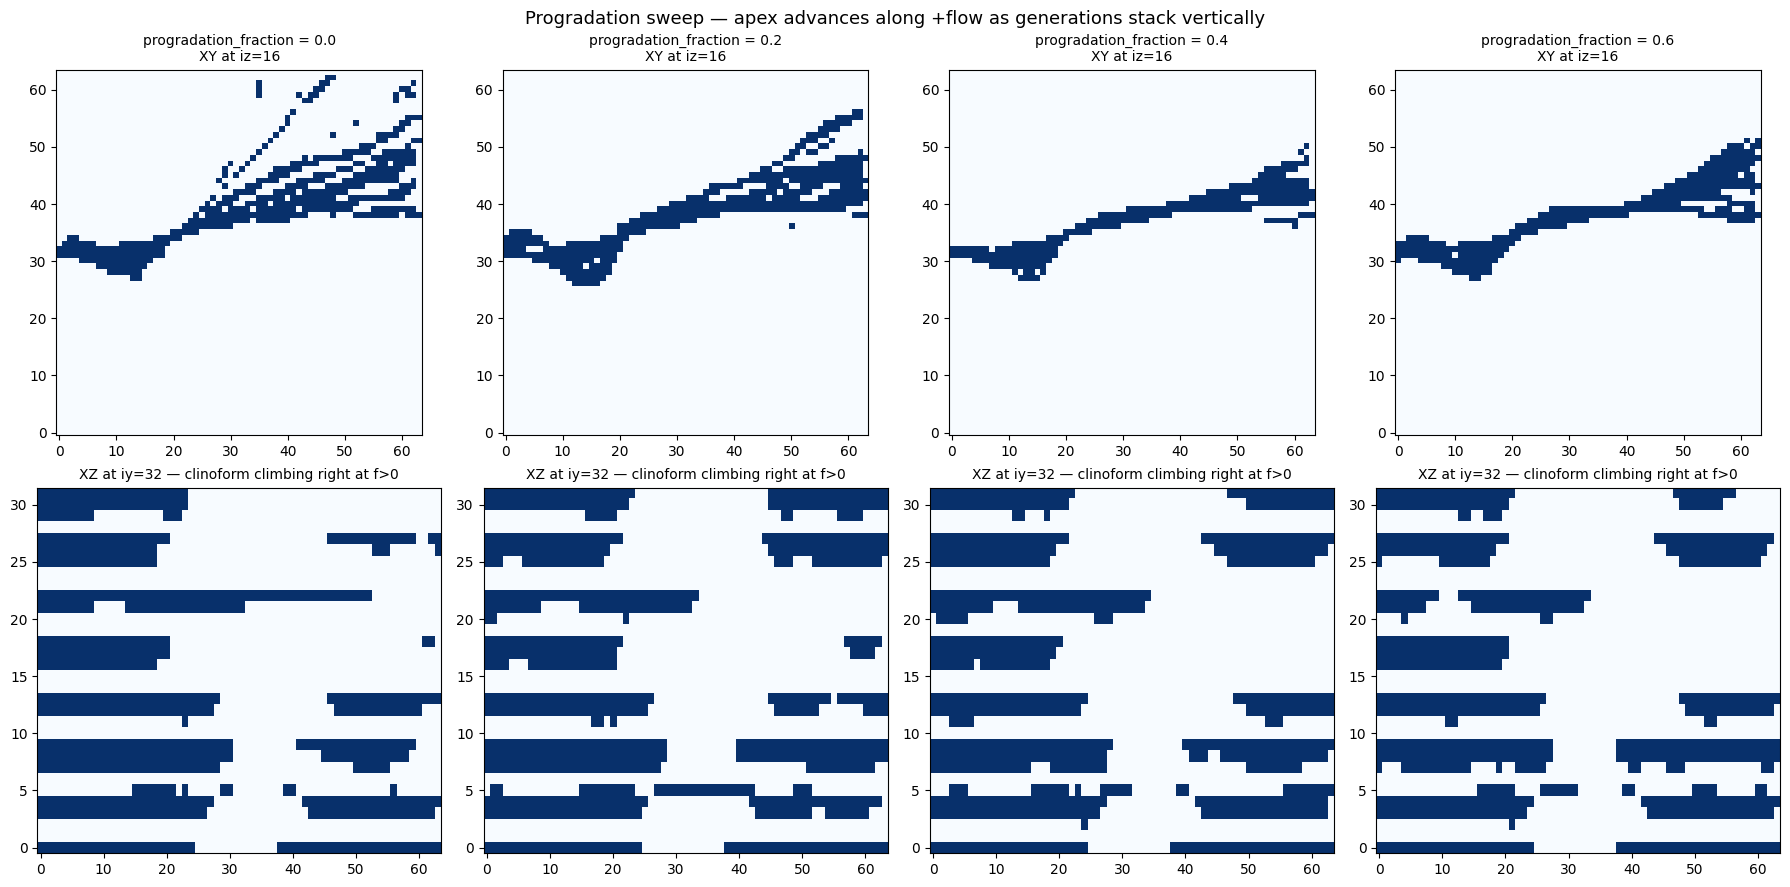

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
iz = GRID['nz'] // 2
iy = GRID['ny'] // 2
for col, pg in enumerate([0.0, 0.2, 0.4, 0.6]):
    layer = DeltaLayer(**GRID)
    layer.create_geology(seed=7, progradation_fraction=pg)
    a = layer.active.astype(np.int32)
    axes[0, col].imshow(a[:, :, iz].T, origin='lower', cmap='Blues', vmin=0, vmax=1, aspect='equal')
    axes[0, col].set_title(f'progradation_fraction = {pg}\nXY at iz={iz}', fontsize=10)
    axes[1, col].imshow(a[:, iy, :].T, origin='lower', cmap='Blues', vmin=0, vmax=1, aspect='auto')
    axes[1, col].set_title(f'XZ at iy={iy} — clinoform climbing right at f>0', fontsize=10)
fig.suptitle('Progradation sweep — apex advances along +flow as generations stack vertically',
              fontsize=13)
fig.tight_layout(); plt.show()

## 5. Mouth bars — `paint_mouth_bars`

Real distributaries terminate in **mouth bars** — fan-shaped lobes of
sand deposited where the channel meets standing water and decelerates.
Set `paint_mouth_bars = True` to paint a calc_lobe envelope (Alluvsim
`calc_lobe.for` parabolic-proximal / elliptical-distal) at every
distal streamline tip recorded by the engine. One bar per generation,
so `n_generations = 8` paints up to 8 bars at the prograding front.
Bar facies = LA (lateral accretion, code 3) — sand in binary mode,
~25 % poro and ~500 mD perm via `FACIES_PROPS`.

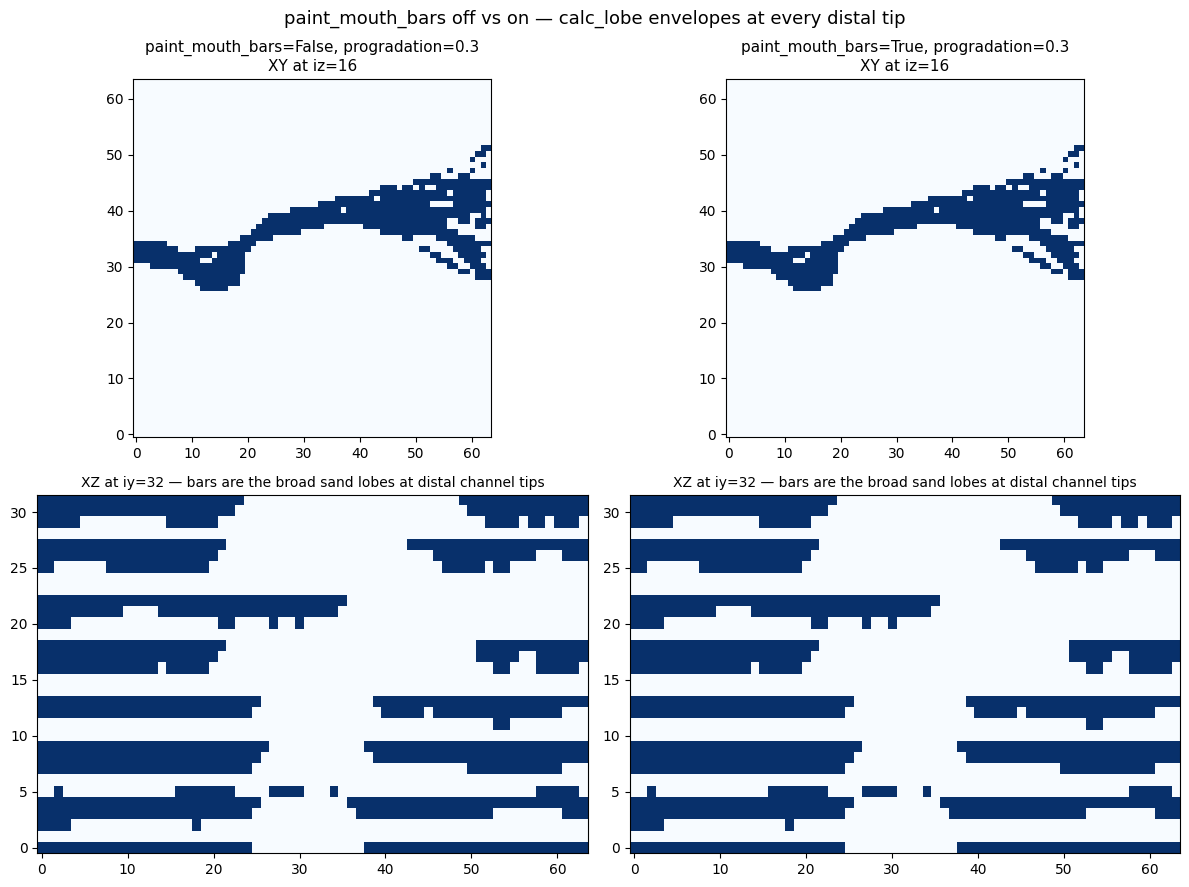

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
iz = GRID['nz'] // 2
iy = GRID['ny'] // 2
for col, mb in enumerate([False, True]):
    layer = DeltaLayer(**GRID)
    layer.create_geology(seed=7, paint_mouth_bars=mb, progradation_fraction=0.3)
    a = layer.active.astype(np.int32)
    axes[0, col].imshow(a[:, :, iz].T, origin='lower', cmap='Blues', vmin=0, vmax=1, aspect='equal')
    axes[0, col].set_title(f'paint_mouth_bars={mb}, progradation=0.3\nXY at iz={iz}', fontsize=11)
    axes[1, col].imshow(a[:, iy, :].T, origin='lower', cmap='Blues', vmin=0, vmax=1, aspect='auto')
    axes[1, col].set_title(f'XZ at iy={iy} — bars are the broad sand lobes at distal channel tips', fontsize=10)
fig.suptitle('paint_mouth_bars off vs on — calc_lobe envelopes at every distal tip',
              fontsize=13)
fig.tight_layout(); plt.show()

## 6. Channel-shape variants — deeper / wider / less-dense

Three `mCHdepth` / `mCHwdratio` / event-budget knobs that change
what an individual distributary looks like and how many of them
show up:

* **deeper channels** — bump `mCHdepth` (default 2 m → 4 m) so
  each distributary cuts deeper into the substrate. Sand bodies
  span more Z cells per pass; XZ slices show thicker channel
  ribbons.
* **wider channels** — bump `mCHwdratio` (default 14 → 28) so the
  full channel width = `wdratio × depth` doubles. Plan-view ribbons
  are visibly wider; the fan looks more sheet-like.
* **less-dense fan** — drop `ntime_per_gen` (default 80 → 30) and
  `n_generations` (default 8 → 4) so far fewer avulsion events fire
  per column. The fan resolves into a few discrete branches with
  obvious shale gaps between them.

All three plotted side-by-side against the DELTA_FAN baseline at
the same seed.

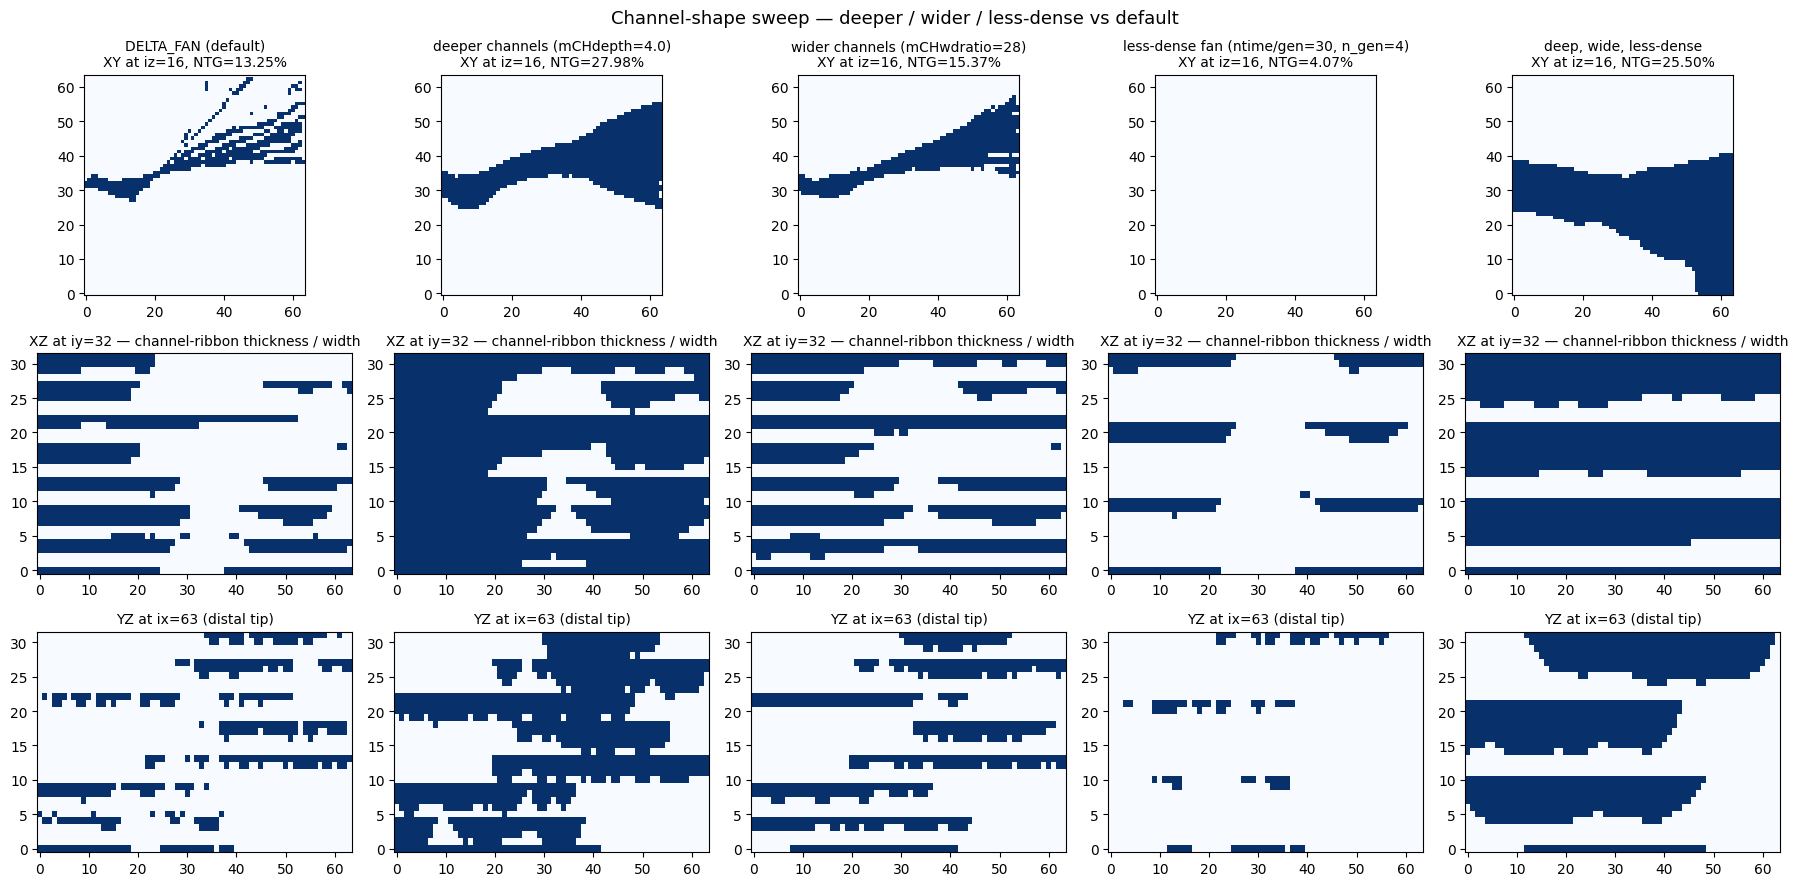

In [8]:
VARIANTS = {
    'DELTA_FAN (default)': dict(),
    'deeper channels (mCHdepth=4.0)':
        dict(mCHdepth=4.0, stdevCHdepth=0.5),
    'wider channels (mCHwdratio=28)':
        dict(mCHwdratio=28.0, stdevCHwdratio=3.0),
    'less-dense fan (ntime/gen=30, n_gen=4)':
        dict(ntime_per_gen=30, n_generations=4),
    'deep, wide, less-dense':
        dict(mCHdepth=6.0, stdevCHdepth=1, mCHwdratio=28.0, stdevCHwdratio=3.0,
              ntime_per_gen=30, n_generations=4, mCHsinu=1.2),
}
fig, axes = plt.subplots(3, 5, figsize=(18, 9))
iz = GRID['nz'] // 2
iy = GRID['ny'] // 2
ix = GRID['nx'] - 1   # YZ at the distal tip
for col, (label, override) in enumerate(VARIANTS.items()):
    layer = DeltaLayer(**GRID)
    layer.create_geology(seed=7, **override)
    a = layer.active.astype(np.int32)
    m = fan_metrics(layer)
    axes[0, col].imshow(a[:, :, iz].T, origin='lower', cmap='Blues', vmin=0, vmax=1, aspect='equal')
    axes[0, col].set_title(f'{label}\nXY at iz={iz}, NTG={m["ntg"]:.2%}', fontsize=10)
    axes[1, col].imshow(a[:, iy, :].T, origin='lower', cmap='Blues', vmin=0, vmax=1, aspect='auto')
    axes[1, col].set_title(f'XZ at iy={iy} — channel-ribbon thickness / width', fontsize=10)
    axes[2, col].imshow(a[ix, :, :].T, origin='lower', cmap='Blues', vmin=0, vmax=1, aspect='auto')
    axes[2, col].set_title(f'YZ at ix={ix} (distal tip)', fontsize=10)
fig.suptitle('Channel-shape sweep — deeper / wider / less-dense vs default',
              fontsize=13)
fig.tight_layout(); plt.show()

## 7. Branch fan-out angle — `branch_spread_deg`

Direct dial for the angle at which a new distributary launches
from its parent at every avulsion-inside splice.

By default the new tail starts walking along the **exact**
parent-channel direction at the splice node — so the only
spread between siblings comes from the AR(2) wandering of each
tail (`mCHsinu`) plus the curvature already accumulated in the
parent. Setting `branch_spread_deg = σ` adds an `N(0, σ°)`
perturbation to the launch azimuth, giving immediate angular
fan-out independent of channel sinuosity:

* `0°` (default) — Alluvsim behaviour
* `10–20°` — subtle widening, branches still cluster
* `30–45°` — clearly fanned distributary network
* `60°+` — wide fan, each branch heads off in its own direction

Combine with low `ntime_per_gen` and low `n_generations` for the
**"wide angle, low density"** look you wanted: the branches are
few but spread across a big arc.

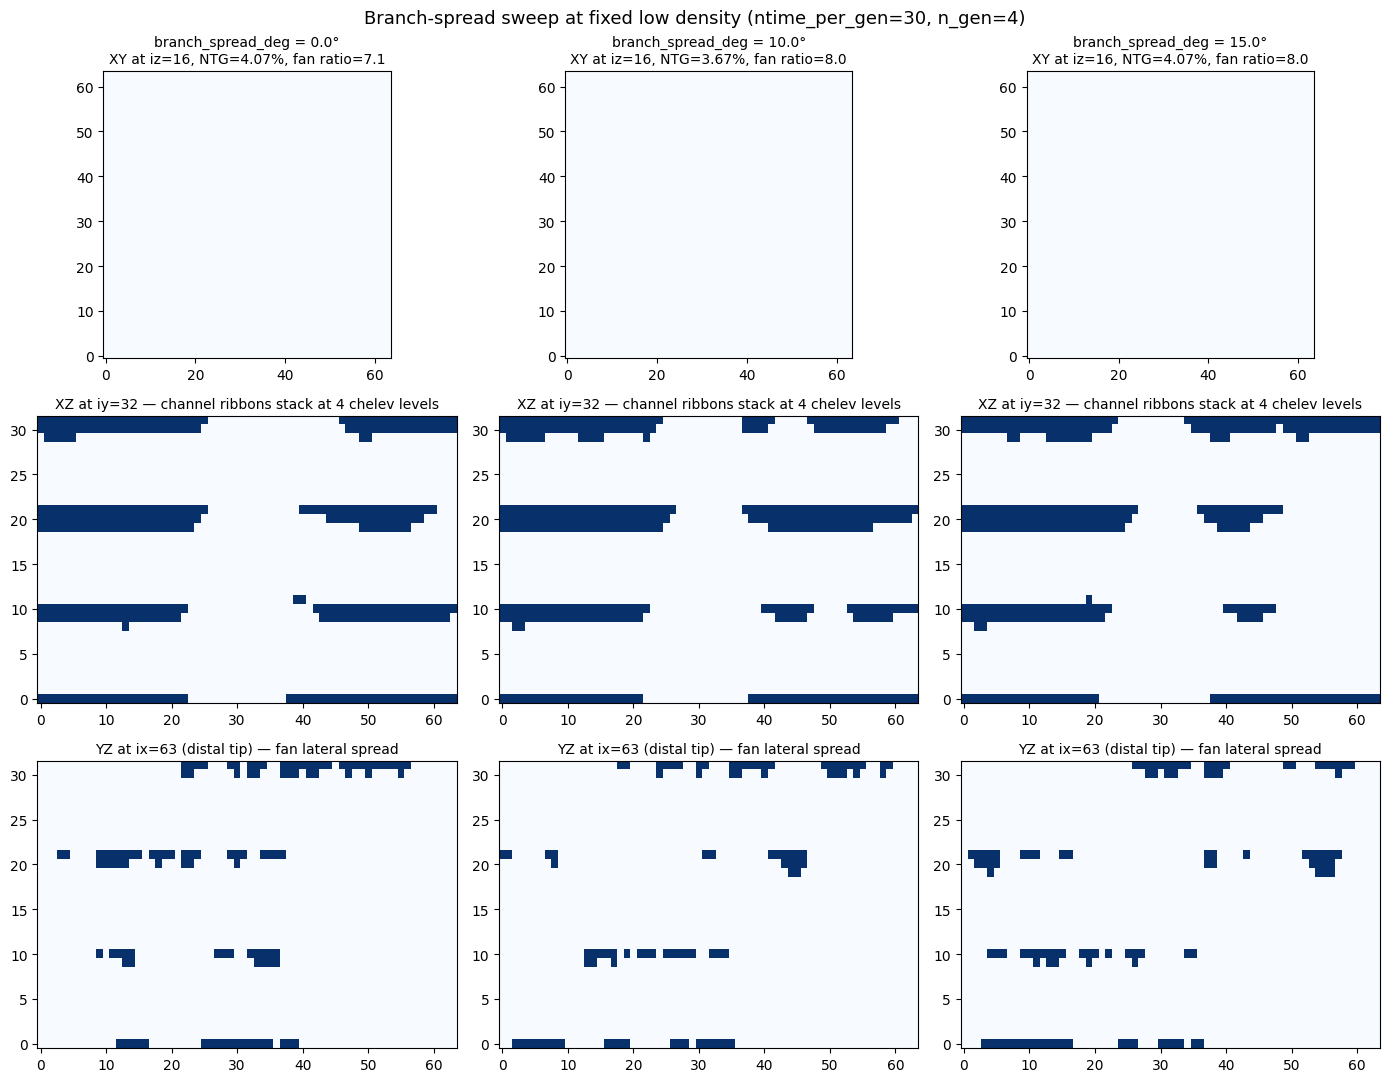

In [9]:
# Wide-angle / low-density recipe: combine branch_spread_deg with
# small ntime_per_gen + small n_generations.
BASE = dict(seed=7, ntime_per_gen=30, n_generations=4, mCHsinu=1.10)
fig, axes = plt.subplots(3, 3, figsize=(14, 11))
for col, spread in enumerate([0.0, 10.0, 15.0]):
    layer = DeltaLayer(**GRID)
    layer.create_geology(branch_spread_deg=spread, **BASE)
    a = layer.active.astype(np.int32)
    m = fan_metrics(layer)
    iz = a.shape[2] // 2
    iy = a.shape[1] // 2
    ix = a.shape[0] - 1   # YZ at the distal tip
    axes[0, col].imshow(a[:, :, iz].T, origin='lower', cmap='Blues', vmin=0, vmax=1, aspect='equal')
    axes[0, col].set_title(f'branch_spread_deg = {spread}°\nXY at iz={iz}, '
                            f'NTG={m["ntg"]:.2%}, fan ratio={m["fan_ratio"]:.1f}',
                            fontsize=10)
    axes[1, col].imshow(a[:, iy, :].T, origin='lower', cmap='Blues', vmin=0, vmax=1, aspect='auto')
    axes[1, col].set_title(f'XZ at iy={iy} — channel ribbons stack at {BASE["n_generations"]} chelev levels',
                            fontsize=10)
    axes[2, col].imshow(a[ix, :, :].T, origin='lower', cmap='Blues', vmin=0, vmax=1, aspect='auto')
    axes[2, col].set_title(f'YZ at ix={ix} (distal tip) — fan lateral spread',
                            fontsize=10)
fig.suptitle('Branch-spread sweep at fixed low density (ntime_per_gen=30, n_gen=4)',
              fontsize=13)
fig.tight_layout(); plt.show()

## 8. Stochastic ensemble — same DELTA_FAN, 8 different seeds

Each seed gives a different concrete realisation of the same
delta-front architecture. The trunk + fan signature is robust across
seeds; the specific branch positions are random — exactly the
stochastic variation you want for dataset generation.

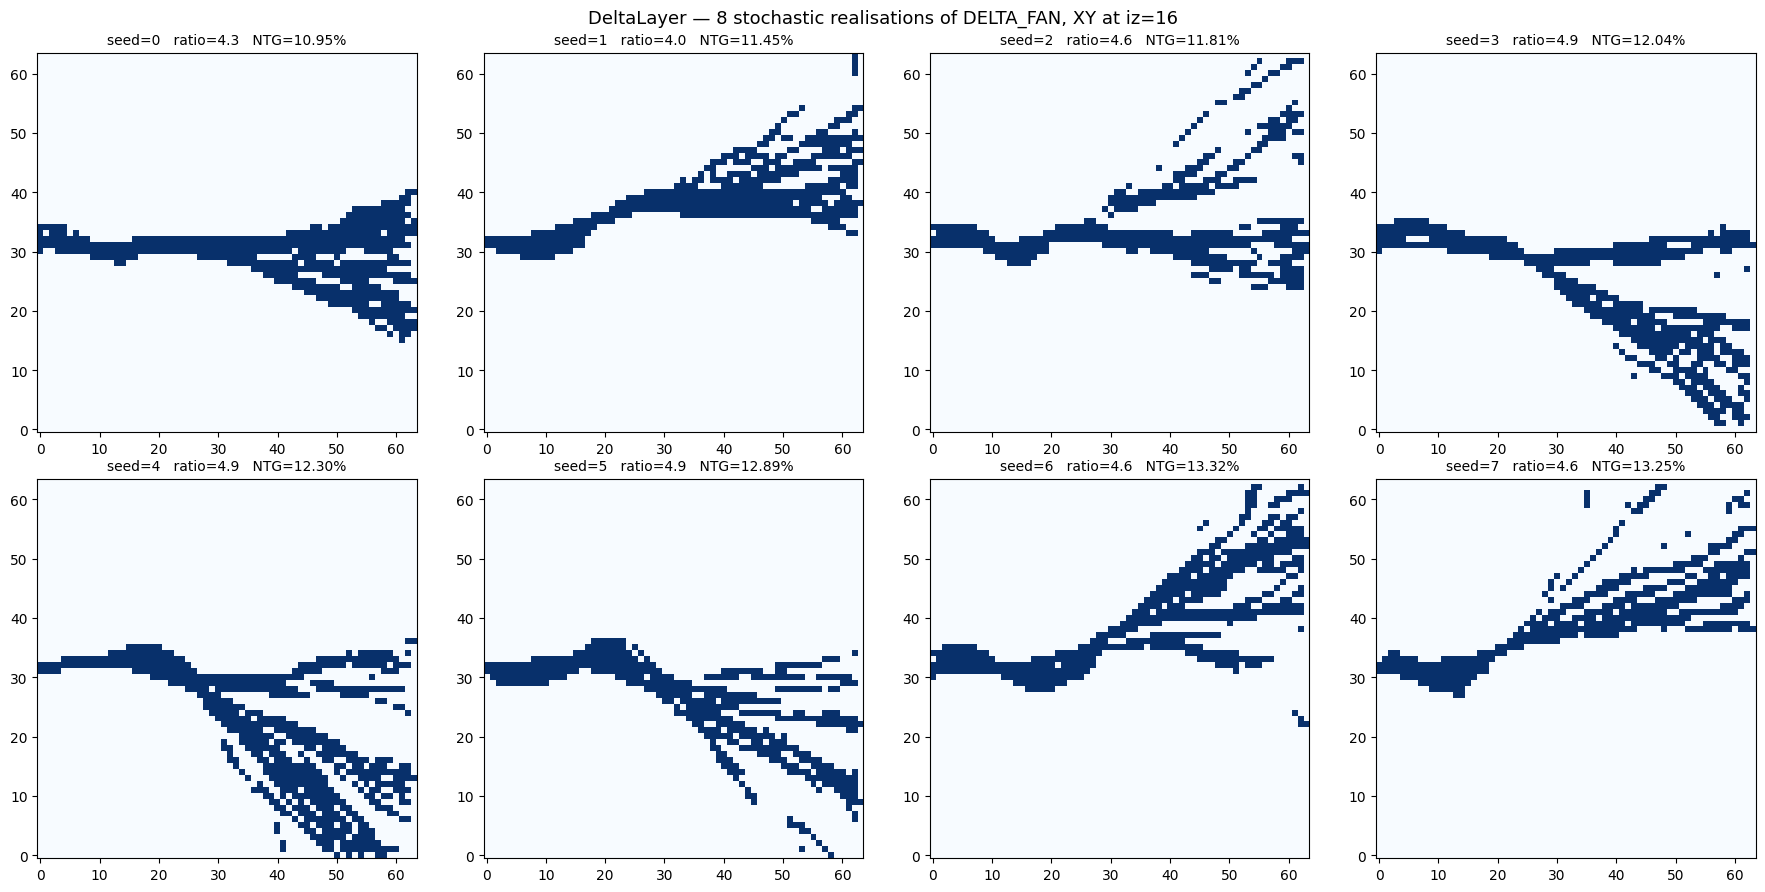

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
iz = GRID['nz'] // 2
for i, seed in enumerate(range(8)):
    layer = DeltaLayer(**GRID)
    layer.create_geology(seed=seed)
    ax = axes.flat[i]
    ax.imshow(layer.active[:, :, iz].T, origin='lower', cmap='Blues', vmin=0, vmax=1, aspect='equal')
    m = fan_metrics(layer)
    ax.set_title(f'seed={seed}   ratio={m["fan_ratio"]:.1f}   NTG={m["ntg"]:.2%}',
                 fontsize=10)
fig.suptitle(f'DeltaLayer — 8 stochastic realisations of DELTA_FAN, XY at iz={iz}', fontsize=13)
fig.tight_layout(); plt.show()

## 9. Azimuth rotation

Compass convention: `0°` = +x (east), `90°` = -y (south), `180°` = -x
(west), `270°` = +y (north). Stamps rotate in the engine frame so
this works without grid post-processing.

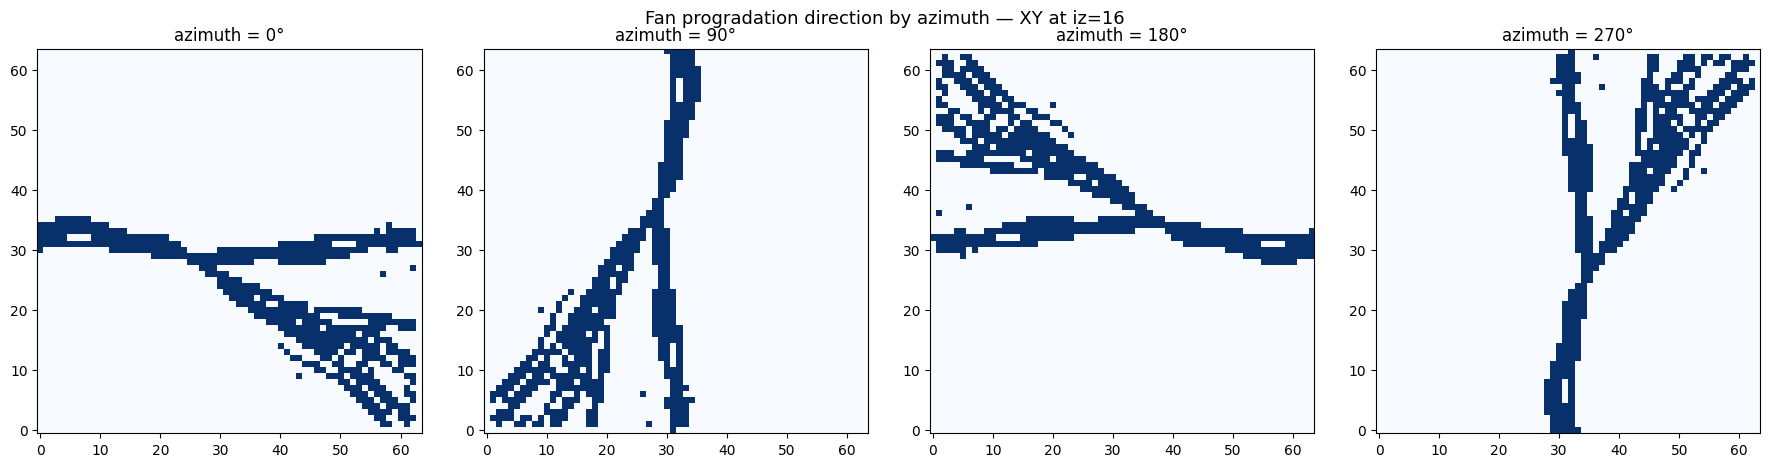

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
iz = GRID['nz'] // 2
for ax, az in zip(axes, [0.0, 90.0, 180.0, 270.0]):
    layer = DeltaLayer(**GRID)
    layer.create_geology(seed=3, azimuth=az)
    ax.imshow(layer.active[:, :, iz].T, origin='lower', cmap='Blues', vmin=0, vmax=1, aspect='equal')
    ax.set_title(f'azimuth = {az:.0f}°')
fig.suptitle(f'Fan progradation direction by azimuth — XY at iz={iz}', fontsize=13)
fig.tight_layout(); plt.show()

## 10. Stacked reservoir — Gaussian background + new delta

reservoir poro_mat shape: (96, 96, 36)
reservoir NTG: 0.8999987943672839


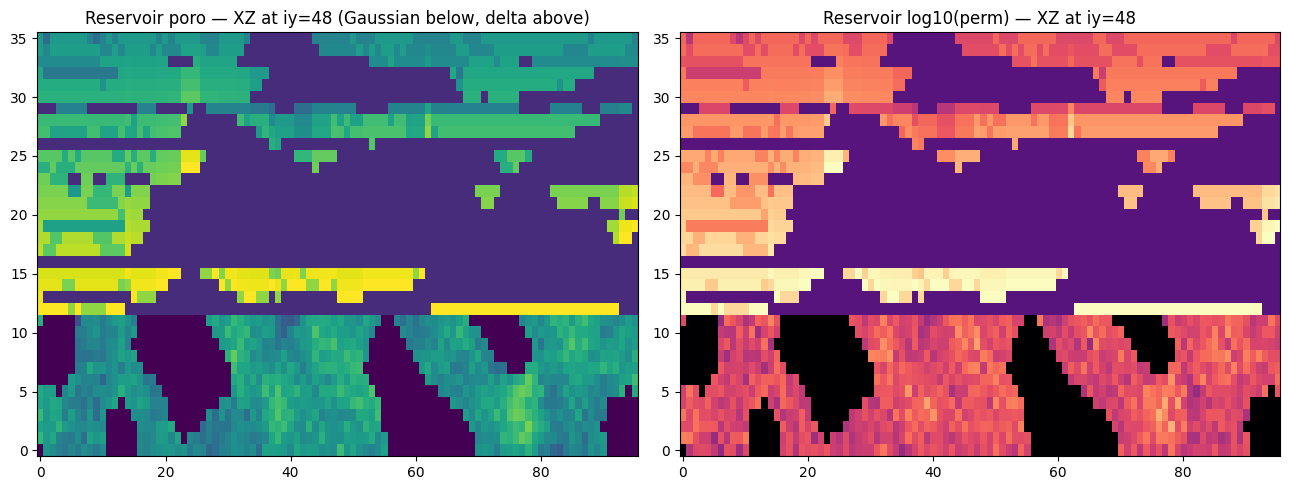

In [12]:
g = rm.GaussianLayer(nx=96, ny=96, nz=12, x_len=960, y_len=960,
                      z_len=24, top_depth=0)
g.create_geology(poro_ave=0.20, perm_ave=1.5, poro_std=0.03,
                  perm_std=0.5, ntg=0.7)

d = DeltaLayer(nx=96, ny=96, nz=24, x_len=960, y_len=960, z_len=24, top_depth=24)
d.create_geology(seed=3, progradation_fraction=0.3, paint_mouth_bars=True)

res = rm.Reservoir([g, d])
print('reservoir poro_mat shape:', res.poro_mat.shape)
print('reservoir NTG:', float((res.poro_mat > 0.05).mean()))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].imshow(res.poro_mat[:, 48, :].T, origin='lower', cmap='viridis',
                aspect='auto')
axes[0].set_title('Reservoir poro — XZ at iy=48 (Gaussian below, delta above)')
axes[1].imshow(np.log10(np.clip(res.perm_mat[:, 48, :].T, 1e-3, None)),
                origin='lower', cmap='magma', aspect='auto')
axes[1].set_title('Reservoir log10(perm) — XZ at iy=48')
fig.tight_layout()
plt.show()